MODEL Training and Evaluation

In [1]:
!git clone https://github.com/mohammedumairuddin/EEEM073-AI-Sustainability-coursework.git

Cloning into 'EEEM073-AI-Sustainability-coursework'...
remote: Enumerating objects: 193, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 193 (delta 12), reused 2 (delta 2), pack-reused 151 (from 2)
Receiving objects: 100% (193/193), 3.08 MiB | 8.29 MiB/s, done.
Resolving deltas: 100% (86/86), done.


In [3]:
!ls

EEEM073-AI-Sustainability-coursework  sample_data


In [4]:
cd EEEM073-AI-Sustainability-coursework/

/content/EEEM073-AI-Sustainability-coursework


In [5]:
!ls

datasets  models  notebooks  README.md	requirements.txt  results


In [6]:
%cd datasets

/content/EEEM073-AI-Sustainability-coursework/datasets


In [7]:
!ls

crop_production.csv


In [8]:
import pandas as pd

df = pd.read_csv("crop_production.csv")
df.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [9]:
import numpy as np

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

In [10]:
#Train test split of data for model training
from sklearn.model_selection import train_test_split

df["Yield"] = df["Production"] / df["Area"]

X = df.drop("Yield", axis=1)
y = df["Yield"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
print(df.dtypes)

State_Name        object
District_Name     object
Crop_Year          int64
Season            object
Crop              object
Area             float64
Production       float64
Yield            float64
dtype: object


In [12]:
print(X_train.select_dtypes(include="object").columns)

Index(['State_Name', 'District_Name', 'Season', 'Crop'], dtype='object')


In [13]:
#importing label encoder
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ["State_Name","District_Name","Season","Crop"]:
    df[col] = le.fit_transform(df[col])

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop("Yield", axis=1)
y = df["Yield"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
print(X_train.dtypes)

State_Name         int64
District_Name      int64
Crop_Year          int64
Season             int64
Crop               int64
Area             float64
Production       float64
dtype: object


In [16]:
X = df.drop("Yield", axis=1)
y = df["Yield"]

X = X.apply(pd.to_numeric, errors="coerce")

X = X.fillna(0)

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
#importing linear regression model
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [19]:
#importing Randomforest regression model
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [20]:
#Hyper parameter tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators":[100,200],
    "max_depth":[5,10,15]
}

grid = GridSearchCV(
    RandomForestRegressor(),
    param_grid,
    cv=3,
    scoring="r2"
)

grid.fit(X_train,y_train)

best_model = grid.best_estimator_

In [21]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

In [22]:
def evaluate_model(y_true,y_pred):

    r2 = r2_score(y_true,y_pred)
    rmse = np.sqrt(mean_squared_error(y_true,y_pred))

    print("R2:",r2)
    print("RMSE:",rmse)

In [23]:
print("Linear Regression")
evaluate_model(y_test,y_pred_lr)

print("Random Forest")
evaluate_model(y_test,y_pred_rf)

Linear Regression
R2: 0.1687610290841639
RMSE: 670.582199367119
Random Forest
R2: 0.9516245855497497
RMSE: 161.7712801679476


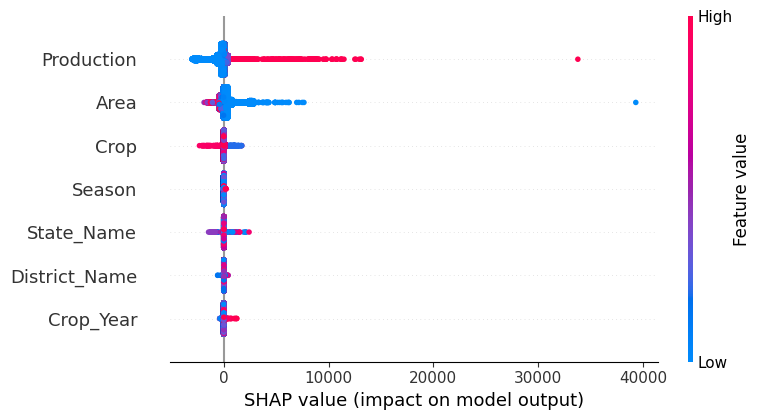

In [24]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [25]:
import time

start = time.time()
rf.fit(X_train,y_train)
end = time.time()

print("Training Time:", end-start)

Training Time: 129.53166890144348


In [26]:
import joblib
import os

# Create the 'models' directory if it doesn't exist
if not os.path.exists('models'):
    os.makedirs('models')

joblib.dump(rf,"models/rf_model.pkl")

['models/rf_model.pkl']

Feature scaling


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred_rf)

print("MAE:", mae)

MAE: 5.784999982810255


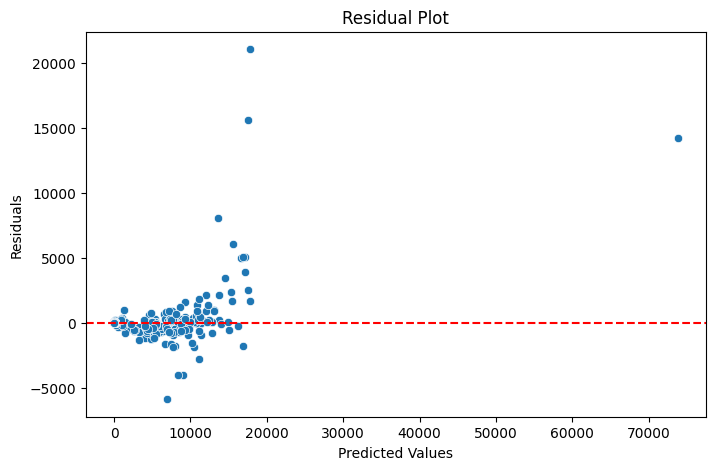

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

residuals = y_test - y_pred_rf

plt.figure(figsize=(8,5))
sns.scatterplot(x=y_pred_rf, y=residuals)

plt.axhline(0, color='red', linestyle='--')

plt.title("Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.savefig("../results/plots/residual_plot.png", dpi=300)
plt.show()

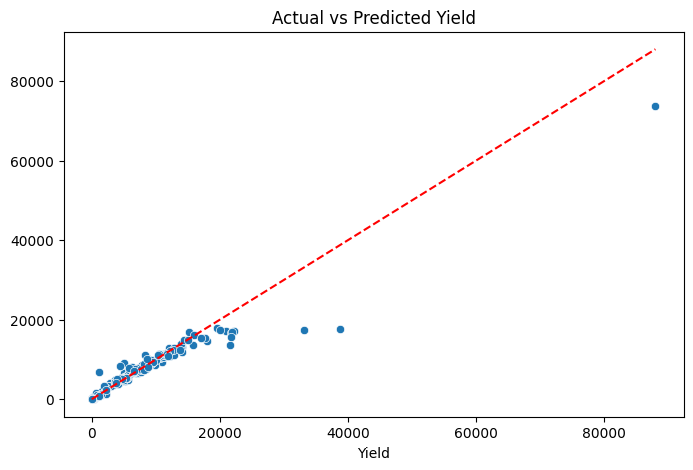

In [31]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_test, y=y_pred_rf)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

plt.title("Actual vs Predicted Yield")

plt.savefig("../results/plots/actual_vs_predicted.png", dpi=300)
plt.show()

In [32]:
plt.savefig("../results/plots/filename.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [33]:
import shutil

shutil.make_archive("results_backup", 'zip', "../results")

'/content/EEEM073-AI-Sustainability-coursework/datasets/results_backup.zip'

In [34]:
from google.colab import files

files.download("results_backup.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>